In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import os
import glob
# import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from tqdm import tqdm


In [2]:
# Set directories
base_dir = '/Users/sethbushinsky/'

data_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Datasets/"
home_dir = base_dir + "UHM_Ocean_BGC_Group Dropbox/Seth Bushinsky/Work/"


manuscript_dir = home_dir + "Manuscripts/2025_01 BGC Argo Plus Dataset Creation/"
manuscript_figs = manuscript_dir + "Figures/"
argo_path = data_dir + "Data_Products/BGC_ARGO_GLOBAL/2025_01_24/Sprof/"
plot_ver = 'v_2026_03'

In [3]:
argolist = []
for file in os.listdir(argo_path):
    if file.endswith('Sprof.nc'):
        argolist.append(file)

print(len(argolist))

2429


In [21]:
# var_select = ['DOXY_ADJUSTED', 'NITRATE_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED']
# var_select = 
var_select = ['DOWN_IRRADIANCE', 'CHLA', 'BBP']


In [22]:
import glob
print(var_select)
# Use glob for faster file listing
argolist = glob.glob(os.path.join(argo_path, '*Sprof.nc'))
print(len(argolist))

# Pre-compile the data collection for efficiency
argo_all = {var: [] for var in var_select}

for n in tqdm(range(0, len(argolist))):
    try:
        # Open dataset with minimal coordinates for faster loading
        argo_n = xr.open_dataset(argolist[n])
        
        # Quick check if any of our variables exist before expensive operations
        available_vars = list(argo_n.data_vars)
        has_target_vars = any(
            any(var_name.startswith(var) for var_name in available_vars) 
            for var in var_select
        )
        
        if not has_target_vars:
            argo_n.close()
            continue
            
        # Set coordinates only when needed
        argo_n = argo_n.set_coords(('PRES_ADJUSTED','LATITUDE','LONGITUDE','JULD'))
        
        # Filter variables with correct dimensions
        var_list = [var for var in available_vars 
                   if set(argo_n[var].dims) == {'N_PROF', 'N_LEVELS'}]
        
        # Find matched variables once per file
        matched_vars = []
        for var in var_select:
            matches = [var_n for var_n in var_list if (
                var_n.startswith(var) and 
                not var_n.endswith('QC') and 
                not var_n.endswith('dPRES')
            )]
            if matches:
                matched_vars.append((var, matches[0]))
        
        if not matched_vars:
            argo_n.close()
            continue
            
        # Get WMO once per file
        wmo_n = argo_n.PLATFORM_NUMBER.values.astype(int)[0]
        
        # Process each matched variable
        for var_key, var_name in matched_vars:
            # Check if variable has any valid data before expensive operations
            var_data = argo_n[var_name]
            valid_profiles = ~np.isnan(var_data).all(dim='N_LEVELS')
            
            if not valid_profiles.any():
                continue
                
            # Extract only profiles with valid data
            valid_indices = np.where(valid_profiles)[0]
            
            if len(valid_indices) > 0:
                # Collect data efficiently
                profile_data = {
                    'wmo': np.repeat(wmo_n, len(valid_indices)),
                    'LATITUDE': argo_n.LATITUDE.isel(N_PROF=valid_indices).values,
                    'LONGITUDE': argo_n.LONGITUDE.isel(N_PROF=valid_indices).values,
                    'juld': argo_n.JULD.isel(N_PROF=valid_indices).values
                }
                
                argo_all[var_key].append(profile_data)
        
        argo_n.close()  # Explicitly close to free memory
        
    except Exception as e:
        print(f'{argolist[n]} failed to load: {e}')
        continue
    
    # if n > 50:  # Keep your break condition
    #     break

# Convert collected data to xarray datasets efficiently
for var_key in var_select:
    if argo_all[var_key]:
        # Concatenate all data for this variable
        combined_data = {
            'wmo': np.concatenate([data['wmo'] for data in argo_all[var_key]]),
            'LATITUDE': np.concatenate([data['LATITUDE'] for data in argo_all[var_key]]),
            'LONGITUDE': np.concatenate([data['LONGITUDE'] for data in argo_all[var_key]]),
            'juld': np.concatenate([data['juld'] for data in argo_all[var_key]])
        }
        
        # Create final xarray dataset
        argo_all[var_key] = xr.Dataset({
            'wmo': (['N_PROF'], combined_data['wmo']),
            'LATITUDE': (['N_PROF'], combined_data['LATITUDE']),
            'LONGITUDE': (['N_PROF'], combined_data['LONGITUDE']),
            'juld': (['N_PROF'], combined_data['juld'])
        })
    else:
        # Create empty dataset if no data found
        argo_all[var_key] = xr.Dataset()

argo_all


['DOWN_IRRADIANCE', 'CHLA', 'BBP']
2429


100%|██████████| 2429/2429 [06:54<00:00,  5.86it/s]


{'DOWN_IRRADIANCE': <xarray.Dataset> Size: 2MB
 Dimensions:    (N_PROF: 61113)
 Dimensions without coordinates: N_PROF
 Data variables:
     wmo        (N_PROF) int64 489kB 4901806 4901806 4901806 ... 2902878 2902878
     LATITUDE   (N_PROF) float64 489kB 72.76 72.58 72.61 ... 40.48 41.71 41.37
     LONGITUDE  (N_PROF) float64 489kB -66.99 -66.4 -66.26 ... 145.0 145.4 144.5
     juld       (N_PROF) datetime64[ns] 489kB 2019-07-17T13:18:12.194225664 .....,
 'CHLA': <xarray.Dataset> Size: 5MB
 Dimensions:    (N_PROF: 143179)
 Dimensions without coordinates: N_PROF
 Data variables:
     wmo        (N_PROF) int64 1MB 6902931 6902931 6902931 ... 2902240 2902240
     LATITUDE   (N_PROF) float64 1MB 46.9 46.9 46.91 ... -0.7759 -1.095 -0.5311
     LONGITUDE  (N_PROF) float64 1MB -4.322 -4.309 -4.31 ... 82.27 83.19 84.43
     juld       (N_PROF) datetime64[ns] 1MB 2018-05-13T12:05:00 ... 2022-08-01...,
 'BBP': <xarray.Dataset> Size: 4MB
 Dimensions:    (N_PROF: 140602)
 Dimensions without coord

## Figure 1

In [23]:
# need to calculate number of float profiles of different kinds over time:
# Create dynamic column names based on var_select
profile_columns = ['decimal_year'] + [f'{var} Profiles' for var in var_select]
year_month_profile_count = pd.DataFrame(columns=profile_columns)

# loop through years
for year_n in range(2002, 2025):
    print(year_n)
    #loop through months
    for mon_n in range(1,13):
        # set initial counts to zero
        month_count={}
        for var in var_select:
            month_count[var]=0
        for var in var_select:
            # Skip empty datasets
            if len(argo_all[var]) == 0 or 'juld' not in argo_all[var]:
                continue
            # print(mon_n) 
            month_index = np.logical_and(argo_all[var]['juld'].dt.year==year_n, 
                            argo_all[var]['juld'].dt.month==mon_n)
            month_count[var] = np.sum(month_index)

        # Create row data dynamically
        row_data = [year_n + mon_n/12] + [month_count[var] for var in var_select]
        new_df_count = pd.DataFrame([row_data], columns=profile_columns)

        year_month_profile_count = pd.concat([year_month_profile_count, new_df_count], ignore_index=True)

print(year_month_profile_count)

2002


/var/folders/fl/mtw53n5j15n3y2s1xfvrlvs40000gn/T/ipykernel_61366/3851029466.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  year_month_profile_count = pd.concat([year_month_profile_count, new_df_count], ignore_index=True)


2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
     decimal_year                           DOWN_IRRADIANCE Profiles  \
0     2002.083333    <xarray.DataArray 'year' ()> Size: 8B\narray(0)   
1     2002.166667    <xarray.DataArray 'year' ()> Size: 8B\narray(0)   
2     2002.250000    <xarray.DataArray 'year' ()> Size: 8B\narray(0)   
3     2002.333333    <xarray.DataArray 'year' ()> Size: 8B\narray(0)   
4     2002.416667    <xarray.DataArray 'year' ()> Size: 8B\narray(0)   
..            ...                                                ...   
271   2024.666667  <xarray.DataArray 'year' ()> Size: 8B\narray(590)   
272   2024.750000  <xarray.DataArray 'year' ()> Size: 8B\narray(566)   
273   2024.833333  <xarray.DataArray 'year' ()> Size: 8B\narray(576)   
274   2024.916667  <xarray.DataArray 'year' ()> Size: 8B\narray(561)   
275   2025.000000  <xarray.DataArray 'year' ()> Size: 8B\narray(516)   

                         

In [52]:
year_month_profile_count['decimal_year'].values

array([2002.08333333, 2002.16666667, 2002.25      , 2002.33333333,
       2002.41666667, 2002.5       , 2002.58333333, 2002.66666667,
       2002.75      , 2002.83333333, 2002.91666667, 2003.        ,
       2003.08333333, 2003.16666667, 2003.25      , 2003.33333333,
       2003.41666667, 2003.5       , 2003.58333333, 2003.66666667,
       2003.75      , 2003.83333333, 2003.91666667, 2004.        ,
       2004.08333333, 2004.16666667, 2004.25      , 2004.33333333,
       2004.41666667, 2004.5       , 2004.58333333, 2004.66666667,
       2004.75      , 2004.83333333, 2004.91666667, 2005.        ,
       2005.08333333, 2005.16666667, 2005.25      , 2005.33333333,
       2005.41666667, 2005.5       , 2005.58333333, 2005.66666667,
       2005.75      , 2005.83333333, 2005.91666667, 2006.        ,
       2006.08333333, 2006.16666667, 2006.25      , 2006.33333333,
       2006.41666667, 2006.5       , 2006.58333333, 2006.66666667,
       2006.75      , 2006.83333333, 2006.91666667, 2007.     

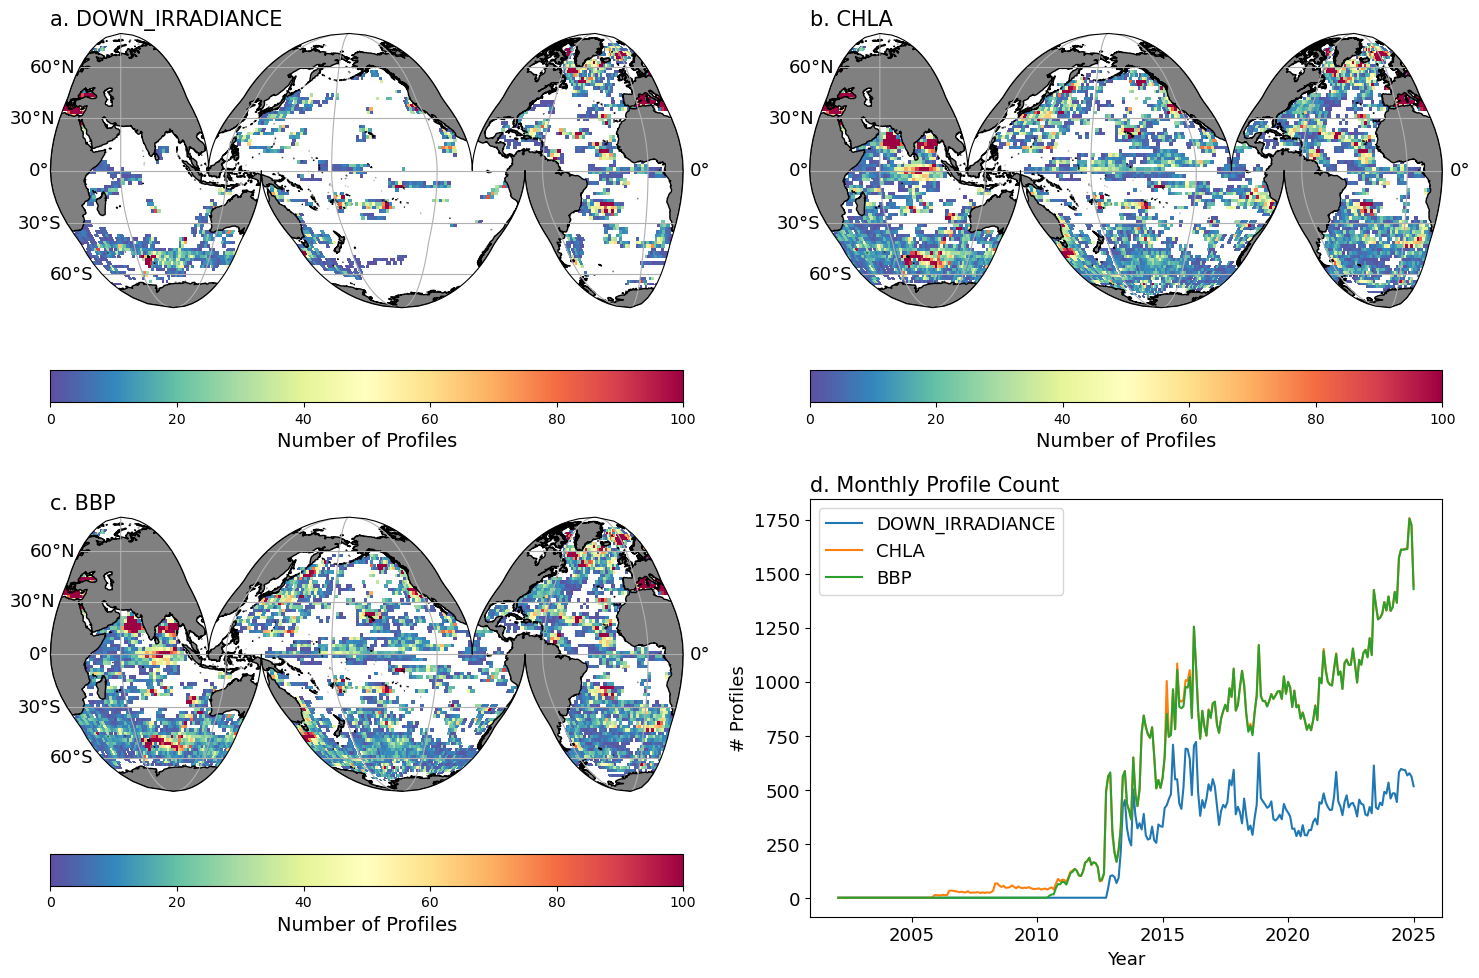

In [24]:
fig = plt.figure(figsize=(15, 10))
title_font_size = 15
axis_label_font_size = 14
plt.rcParams.update({'font.size': 13})

# Create dynamic variable names with lettered labels
letters = ['a', 'b', 'c', 'd', 'e', 'f']  # Add more letters if needed
var_names = [f'{letters[i]}. {var}' for i, var in enumerate(var_select)]

# Calculate subplot grid dynamically
n_vars = len(var_select)
if n_vars <= 3:
    rows, cols = 2, 2
else:
    rows = int(np.ceil((n_vars + 1) / 3))  # +1 for time series plot
    cols = 3

for n, var in enumerate(var_select):
    # Skip if no data available for this variable
    if len(argo_all[var]) == 0 or 'LATITUDE' not in argo_all[var]:
        continue
        
    ax = fig.add_subplot(rows, cols, n+1, projection=ccrs.InterruptedGoodeHomolosine(central_longitude=-160, globe=None, emphasis='ocean'))
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='k', facecolor=[.5, .5 ,.5]))

    ax.set_global()
    gl = ax.gridlines(draw_labels=True, ylocs=[-60, -30, 0, 30, 60], xlocs=[-180, -120, -60, 0, 60, 120], x_inline=False)
    gl.left_labels = True
    gl.top_labels = False
    gl.bottom_labels=False
    
    dlatlon = 2
    lonbins = np.arange(-180, 180, dlatlon)
    latbins = np.arange(-80, 80, dlatlon)

    hist = stats.binned_statistic_2d(argo_all[var].LATITUDE, argo_all[var].LONGITUDE, None, bins=[latbins, lonbins], statistic="count")
    hist.statistic[hist.statistic == 0] = np.nan  # Sets all values of 0 to nan as log10(0) = -inf

    image = plt.pcolormesh(lonbins, latbins, hist.statistic, cmap='Spectral_r', shading="flat", transform=ccrs.PlateCarree()) 
    plt.clim(0, 100) 

    cbar = fig.colorbar(image, ax=ax, orientation='horizontal')
    plt.title(var_names[n], loc='left', size=title_font_size)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(label='Number of Profiles', size=axis_label_font_size)

# Time series subplot
ax = fig.add_subplot(rows, cols, n_vars+1)

# Plot time series for each variable dynamically
for i, var in enumerate(var_select):
    col_name = f'{var} Profiles'
    if col_name in year_month_profile_count.columns:
        plt.plot(year_month_profile_count['decimal_year'].values, 
                year_month_profile_count[col_name].values, 
                label=var_names[i].split('. ')[1])  # Remove letter prefix for legend

plt.legend()
ax.set_ylabel('# Profiles')
ax.set_xlabel('Year')
ax.set_title(f'{letters[n_vars]}. Monthly Profile Count', loc='left', size=title_font_size)

plt.tight_layout()

plt.savefig(manuscript_figs+ 'Fig_1_Argo_Sampling_Density and num_profiles_' + '_'.join(var_select) + plot_ver + '.pdf', dpi = 300)